# Trabajo Práctico 2 - Grupo 02

### Análisis exploratorio de datos

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

El objetivo es caracterizar el dataset antes de modelar, analizamos el tamaño, balance de clases, longitud de textos, presencia de ruido y vocabulario discriminativo por clase. Las decisiones de preprocesamiento y de modelos se justifican a partir de los hallazgos de esta notebook.

## Importación e instalación de dependencias

In [1]:
!pip install -q spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

sys.path.append("/content/drive/MyDrive/CienciaDeDatos/TPs/TP2")

from common.preprocessing import clean_classical

Mounted at /content/drive


## Carga de datos y estudio inicial

In [4]:
train = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/TPs/TP2/data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/TPs/TP2/data/test.csv")

# Análisis del tamaño del dataframe
print(f"Train: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas × {test.shape[1]} columnas\n")
print("Tipos de datos (train):")
print(f"{train.dtypes}\n")
print("Tipos de datos (test):")
print(f"{test.dtypes}\n")

Train: 51,000 filas × 3 columnas
Test:  8,500 filas × 2 columnas

Tipos de datos (train):
id        int64
text     object
label     int64
dtype: object

Tipos de datos (test):
id       int64
text    object
dtype: object



In [5]:
# Tipos de cada variable
train.head(5)

,id,text,label
0,0,Lo primero recibí el paquete en una bolsa toda...,0
1,1,Lo compré y no lo he recibido. Les acabo de es...,0
2,2,Ha tardado muchísimo en venir... Pero ha llega...,0
3,3,"Van bien, como todas las Bosch que he tenido e...",2
4,4,La resistencia la he gastado solamente una vez...,1


In [6]:
# Tipos de cada variable
test.head(5)

,id,text
0,0,Funciona perfecto. No hay problemas de compati...
1,1,"Diseño y materiales, acorde a su precio. En es..."
2,2,La pulsera es fiel a lo que se ofrece. Es bast...
3,3,A mi hijo le encantan los LEGO. Este es fácil ...
4,4,Excelente producción e interpretación. Poco má...


In [7]:
# Nulos y duplicados
print("Nulos en train:")
print(train.isna().sum())
print("\nNulos en test:")
print(test.isna().sum())
print(f"\nDuplicados exactos en train (mismo texto): {train.duplicated(subset='text').sum()}")
print(f"Duplicados exactos en test (mismo texto):  {test.duplicated(subset='text').sum()}")
print(f"\nIDs únicos en train: {train['id'].nunique()}/{len(train)}")
print(f"IDs únicos en test:  {test['id'].nunique()}/{len(test)}")

Nulos en train:
id       0
text     0
label    0
dtype: int64

Nulos en test:
id      0
text    0
dtype: int64

Duplicados exactos en train (mismo texto): 238
Duplicados exactos en test (mismo texto):  20

IDs únicos en train: 51000/51000
IDs únicos en test:  8500/8500


## Distribución de clases

   clase     n    %
negativa 20400 40.0
  neutra 10200 20.0
positiva 20400 40.0


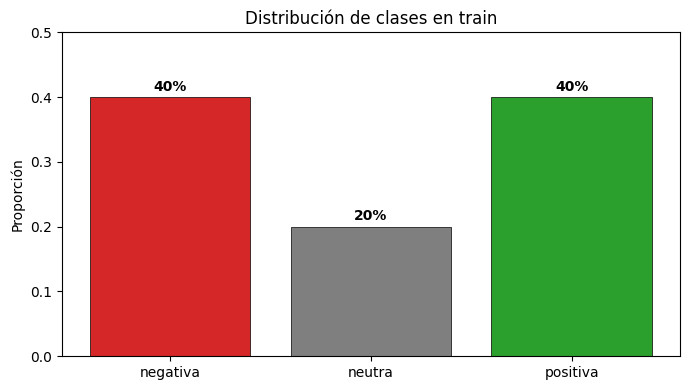

In [8]:
class_counts = train['label'].value_counts().sort_index()
class_props = train['label'].value_counts(normalize=True).sort_index()
class_names = {0: "negativa", 1: "neutra", 2: "positiva"}

summary = pd.DataFrame({
    "clase": [class_names[i] for i in class_counts.index],
    "n": class_counts.values,
    "%": (class_props.values * 100).round(2),
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728", "#7f7f7f", "#2ca02c"]
bars = ax.bar([class_names[i] for i in class_counts.index],
              class_props.values, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Proporción")
ax.set_title("Distribución de clases en train")
ax.set_ylim(0, 0.5)
for bar, p in zip(bars, class_props.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{p:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Las clases negativa y positiva tienen un 40% cada una y la clase neutra solo un 20%. Es un desbalance moderado pero crítico para el TP porque la métrica de Kaggle es **F1-macro**, que pondera las tres clases por igual. Debido a esto, una clasificación trivial de todo positivo o negatico tiene `accuracy` del 40%.

Todos los modelos van a probarse con y sin rebalanceo, además se evaluara con F1 macro siempre



## Longitud de los textos

In [9]:
# Longitudes en tokens (split por whitespace) y caracteres
train['n_tokens'] = train['text'].str.split().str.len()
train['n_chars']  = train['text'].str.len()

print("Distribución de tokens por reseña:")
print(train['n_tokens'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))
print("\nDistribución de caracteres por reseña:")
print(train['n_chars'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

Distribución de tokens por reseña:
count    51000.0
mean        28.0
std         24.4
min          2.0
25%         12.0
50%         22.0
75%         35.0
90%         55.0
95%         73.0
99%        122.0
max        458.0
Name: n_tokens, dtype: float64

Distribución de caracteres por reseña:
count    51000.0
mean       152.0
std        133.0
min         17.0
25%         68.0
50%        120.0
75%        187.0
90%        297.0
95%        396.0
99%        676.0
max       2459.0
Name: n_chars, dtype: float64


La mediana son 28 tokens y el p99 son 122 tokens, por lo que las reseñas son cortas. En BETO con `max_length = 128` cubrimos el 99% de los casos sin sacar información relevante.

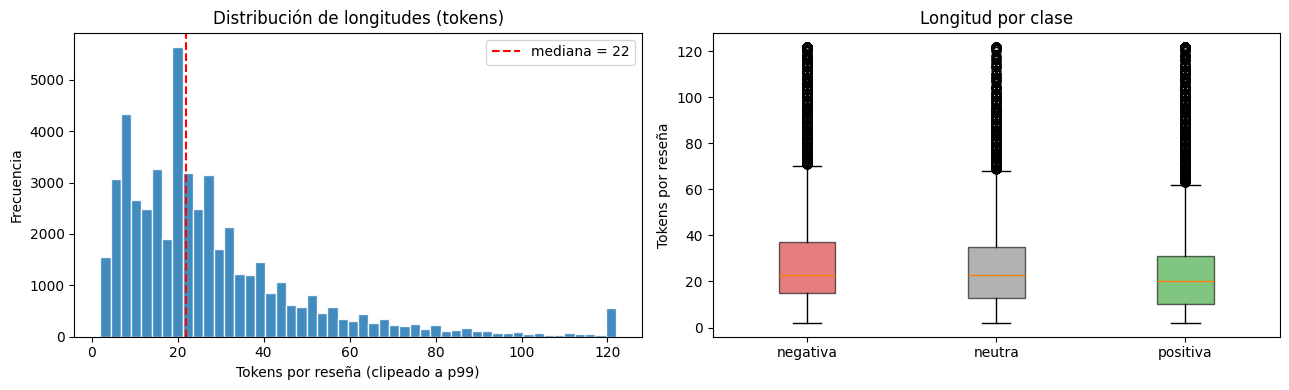


Longitud media de tokens por clase:
        mean  median    std
label                      
0      30.11    23.0  24.70
1      28.67    23.0  24.38
2      25.47    20.0  23.92


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma global de tokens (clip a p99 para que se vea algo)
clip = int(train['n_tokens'].quantile(0.99))

# Distribución de longitudes
axes[0].hist(train['n_tokens'].clip(upper=clip), bins=50, color="#1f77b4", edgecolor="white", alpha=0.85)
axes[0].axvline(train['n_tokens'].median(), color="red", linestyle="--", label=f"mediana = {train['n_tokens'].median():.0f}")
axes[0].set_xlabel("Tokens por reseña (clipeado a p99)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de longitudes (tokens)")
axes[0].legend()

# Boxplot de longitud por clase
order = [0, 1, 2]
data = [train[train['label']==c]['n_tokens'].clip(upper=clip) for c in order]
bp = axes[1].boxplot(data, tick_labels=[class_names[c] for c in order], patch_artist=True, showfliers=True)

for patch, color in zip(bp['boxes'], ["#d62728", "#7f7f7f", "#2ca02c"]):
    patch.set_facecolor(color); patch.set_alpha(0.6)

axes[1].set_ylabel("Tokens por reseña")
axes[1].set_title("Longitud por clase")

plt.tight_layout()
plt.show()

print("\nLongitud media de tokens por clase:")
print(train.groupby('label')['n_tokens'].agg(['mean', 'median', 'std']).round(2))

Las reseñas negativas tienden a ser mas largas que las positivas, ya que la gente se explaya mas al quejarse. En cambio cuando recibe un buen producto o servicio suele decir pocas palabras, incluso puede hasta no dejar reseñas.

## Caracteres especiales y ruido

In [11]:
sample = train['text'].sample(n=10_000, random_state=SEED)

pat = {
    "HTML (<tag>)":       r"<[^>]+>",
    "URL (http/https)":   r"https?://",
    "Emoji (rango Unic.)": r"[\U0001F300-\U0001FAFF]",
    "ALL CAPS (≥3 letras)": r"\b[A-ZÁÉÍÓÚÑ]{3,}\b",
    "Signos repetidos (!! o ??)": r"!!|\?\?",
    "Mención (@user)":    r"@\w+",
    "Hashtag":            r"#\w+",
    "Email":              r"\b[\w.+-]+@[\w.-]+\.[a-zA-Z]{2,}\b",
}

rows = []
for label, regex in pat.items():
    pct = sample.str.contains(regex, regex=True).mean() * 100
    rows.append((label, f"{pct:.2f}%"))
print(pd.DataFrame(rows, columns=["Patrón", "% reseñas que lo contienen"]).to_string(index=False))

                    Patrón % reseñas que lo contienen
              HTML (<tag>)                      0.00%
          URL (http/https)                      0.00%
       Emoji (rango Unic.)                      0.29%
      ALL CAPS (≥3 letras)                      4.14%
Signos repetidos (!! o ??)                      1.90%
           Mención (@user)                      0.00%
                   Hashtag                      0.01%
                     Email                      0.00%


No hay que borrar HTML ni URLs, los emojis casi no aparecen. El paso de limpieza puede ser minimalista.

El único punto a considerar es **ALL CAPS** (~4.1 % de las reseñas): suelen indicar fuerte sentimiento ("ES UNA BASURA", "EXCELENTE"). Al hacer lowercase se pierde esa señal.

## Análisis del vocabulario

In [12]:
# Preprocesado para análisis lexical: stopwords fuera, palabras importantes adentro
print("Aplicando clean_classical al train")
train['text_clean'] = train['text'].apply(clean_classical)
train[['text', 'text_clean']].head(5)

Aplicando clean_classical al train


,text,text_clean
0,Lo primero recibí el paquete en una bolsa toda...,recibir paquete bolsa rota unierar ara tradici...
1,Lo compré y no lo he recibido. Les acabo de es...,comprar no haber recibir acabar escribir mail ...
2,Ha tardado muchísimo en venir... Pero ha llega...,haber tardar muchísimo venir pero haber llegar...
3,"Van bien, como todas las Bosch que he tenido e...",ir bien bosch haber tener versión no dar estre...
4,La resistencia la he gastado solamente una vez...,resistencia haber gastar solamente vez funcion...


In [13]:
# Top 20 palabras más frecuentes por clase
def top_tokens(texts, n=20):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    return counter.most_common(n)

top_per_class = {}
for cls in [0, 1, 2]:
    top_per_class[cls] = top_tokens(train.loc[train.label == cls, 'text_clean'], n=20)

display_df = pd.DataFrame({
    f"clase {class_names[cls]}": [f"{w} ({c})" for w, c in tops]
    for cls, tops in top_per_class.items()
})
display_df.index.name = "rank"
display_df.index = display_df.index + 1
print("Top 20 palabras más discriminativas por clase\n")
print(display_df.to_string())

Top 20 palabras más discriminativas por clase

        clase negativa     clase neutra   clase positiva
rank                                                    
1           no (22575)       ser (9753)      ser (15605)
2          ser (16041)        no (7985)    mucho (13077)
3        haber (10947)      pero (4940)        no (7724)
4         mucho (7702)     mucho (4926)     haber (6013)
5          pero (6444)     haber (3599)      bien (5828)
6         tener (5590)      bien (3405)      buen (5570)
7            él (4597)     tener (2897)     tener (5021)
8          bien (3445)        él (1923)      pero (4693)
9        llegar (3232)      poco (1752)   calidad (3672)
10     producto (3083)   calidad (1418)    precio (2985)
11         nada (2884)     poder (1371)        él (2811)
12        poder (2739)      buen (1366)  perfecto (2656)
13        hacer (2568)    precio (1265)  producto (2326)
14      calidad (2484)     hacer (1149)     poder (2267)
15      comprar (2421)  producto (1017)  

Las palabras más frecuentes en cada clase son poco discriminativas (palabras de dominio general: "producto", "calidad", "precio"). Esto es esperable porque la frecuencia bruta favorece términos comunes. Para encontrar el vocabulario que **distingue** una clase de otra, necesitamos un score discriminativo como χ² sobre TF-IDF.

El test χ² (chi-cuadrado) mide la dependencia entre cada término y una clase. Para cada palabra, compara cuántas veces aparece en documentos de esa clase contra cuántas veces esperaríamos verla si la distribución fuera aleatoria. Un score alto significa que la palabra aparece mucho más (o mucho menos) de lo esperado en esa clase, es decir, que su presencia es informativa para predecir el label. Se aplica one-vs-rest: para encontrar las palabras discriminativas de "negativa", se trata al resto (neutra + positiva) como la clase opuesta. Las palabras con mayor score χ² son las que más ayudan a separar esa clase del resto, y son exactamente las que un modelo como Naive Bayes va a pesar más en sus predicciones.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Vectorizamos para chi² (unigramas, ngram corto para que se interpreten)
# ngramas de rango 1 a 1 son tokens individuales, es decir, palabras
vec = TfidfVectorizer(min_df=20, max_df=0.9, ngram_range=(1, 1), sublinear_tf=True)
X = vec.fit_transform(train['text_clean'])
feature_names = np.array(vec.get_feature_names_out())

print(f"Vocabulario (chi² con unigramas, min_df=20): {len(feature_names)} términos\n")

# chi² one-vs-rest por clase
top_per_class = {}
for cls in [0, 1, 2]:
    y_bin = (train['label'].values == cls).astype(int)
    chi_scores, _ = chi2(X, y_bin)
    top_idx = np.argsort(chi_scores)[-20:][::-1]
    top_per_class[class_names[cls]] = [(feature_names[i], chi_scores[i]) for i in top_idx]

df_chi = pd.DataFrame({
    cls: [f"{w} ({s:.0f})" for w, s in items]
    for cls, items in top_per_class.items()
})
df_chi.index = df_chi.index + 1
df_chi.index.name = "rank"
print("Top 20 palabras más discriminativas por clase (chi² sobre TF-IDF):\n")
print(df_chi.to_string())

Vocabulario (chi² con unigramas, min_df=20): 3172 términos

Top 20 palabras más discriminativas por clase (chi² sobre TF-IDF):

                 negativa             neutra             positiva
rank                                                             
1              buen (482)         pero (192)       perfecto (652)
2                no (462)          poco (62)           buen (644)
3          perfecto (376)        aunque (57)             no (517)
4          devolver (315)      perfecto (57)       encantar (296)
5              nada (312)      recomeir (54)  perfectamente (253)
6            precio (282)          bien (54)         genial (238)
7              malo (228)       pequeño (49)       devolver (217)
8               mes (200)        compra (40)         precio (216)
9            dinero (196)     demasiado (33)           nada (189)
10             bien (195)  recomendable (32)          fácil (188)
11               ni (190)      encantar (31)      encantado (175)
12          re

Como se puede ver las palabras que más predominan en las clases son:

- **Negativa:** dominan términos de decepción y reclamo ("devolver",
  "devolución", "dinero") junto con negaciones e intensificadores negativos
  ("no", "nada", "ni", "nunca", "malo"). Llama la atención la presencia de
  "perfecto" y "buen" con scores altos — no porque indiquen satisfacción,
  sino porque aparecen en construcciones como "no es perfecto" o
  "no es tan buen producto".

- **Positiva:** dominan adjetivos de satisfacción fuerte ("perfecto",
  "perfectamente", "excelente", "genial") y verbos de recomendación
  ("encantar", "encantado", "recomendable"). La presencia de "no" refleja
  frases como "no tuve ningún problema" o "no me decepcionó".

- **Neutra:** el vocabulario es notablemente más débil (scores mucho más
  bajos que en las otras dos clases) y está dominado por conectores
  adversativos ("pero", "aunque") e intensificadores atenuadores ("poco",
  "demasiado"). Esto confirma que las reseñas neutras son reseñas de
  sentimiento **mixto** — valoran algo positivamente y critican otra cosa
  en la misma oración — y no simplemente reseñas sin opinión. Esta es
  exactamente la razón por la que la clase neutra va a ser la más difícil
  de clasificar: comparte vocabulario con ambos extremos.

## Análisis de longitud de texto después del procesamiento

In [15]:
train['n_tokens_clean'] = train['text_clean'].str.split().str.len()

reduction = 1 - (train['n_tokens_clean'].sum() / train['n_tokens'].sum())
print(f"Reducción global de tokens tras clean_classical: {reduction:.1%}")
print("\nAntes vs después (mediana de tokens):")
print(train[['n_tokens', 'n_tokens_clean']].median())

# Reseñas que quedan vacías o casi vacías
empty = (train['n_tokens_clean'] == 0).sum()
short = (train['n_tokens_clean'] < 3).sum()
print(f"\nReseñas vacías tras limpieza: {empty} ({empty/len(train):.2%})")
print(f"Reseñas con < 3 tokens tras limpieza: {short} ({short/len(train):.2%})")

Reducción global de tokens tras clean_classical: 39.4%

Antes vs después (mediana de tokens):
n_tokens          22.0
n_tokens_clean    13.0
dtype: float64

Reseñas vacías tras limpieza: 0 (0.00%)
Reseñas con < 3 tokens tras limpieza: 629 (1.23%)
